#Machine Learning I - Fase 1 - Template


Nome: **Elisa Amaral**

##Análise Exploratória e Preparação dos Dados


Nesta fase, você se apropriará dos dados, conhecendo o dataset. Será nesta fase que você fará a etapa de Exploratory Data Analysis, EDA, que consiste em uma análise exploratória dos dados. A partir das técnicas de EDA você descobrirá as características dos dados quanto ao tipo, atributos, escala, frequência, distribuição, dados faltantes etc.

Faz parte dessa etapa também a preparação dos dados, isso inclui a limpeza dos dados, correção, reescala e transformação, bem como a seleção dos atributos mais relevantes para a tarefa de classificação a ser explorada na fase 2.


#1) Formatação dos atributos


Antes de analisar os atributos, precisamos unificar o formato de representação de cada coluna.

Verifique quais colunas estão com mais de uma representação de seu valor e formate para que todos os valores fiquem na mesma representação.

Por fim, você deve transformar todas as colunas para o formato numérico.

**OBS:** Lembre-se que colunas nominais e ordinais possuem formas diferentes de serem transformadas em numéricas.


In [ ]:
# Insira seu código aqui.
# Você pode criar células de código adicionais


# TODO
# 1) Visualização dos dados de cada coluna
# 2) Formatação de cada coluna
# 3) Remoção das linhas repetidas
# 4) Transformação das colunas categóricas para numéricas

# Observação
Todos os comentários feitos durante o processo estão disponíveis no .ipynb zipado junto a esse Template. Ele é de suma importância para a avaliação desse projeto, nele estão contidos não só os códigos anexados aqui, mas também todo o meu processo de aprendizado e referências.

In [ ]:
import pandas as pd
import jinja2
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv("Titanic-Dataset-Modificado.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1069 entries, 0 to 1068
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1069 non-null   int64  
 1   Survived     1069 non-null   bool   
 2   Pclass       985 non-null    float64
 3   Name         1069 non-null   object 
 4   Sex          985 non-null    object 
 5   Age          855 non-null    object 
 6   SibSp        1069 non-null   int64  
 7   Parch        1069 non-null   int64  
 8   Ticket       1069 non-null   object 
 9   Fare         1069 non-null   float64
 10  Cabin        248 non-null    object 
 11  Embarked     983 non-null    object 
 12  day          1069 non-null   int64  
 13  month        1069 non-null   int64  
 14  year         1069 non-null   int64  
 15  time         1069 non-null   object 
 16  cost         202 non-null    float64
 17  budget       128 non-null    float64
dtypes: bool(1), float64(4), int64(6), object(7)
memory usage: 143.1+ KB

In [ ]:
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'day', 'month', 'year', 'time', 'cost', 'budget'], inplace=True)
# Sobram as seguintes colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1069 entries, 0 to 1068
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  1069 non-null   bool   
 1   Pclass    985 non-null    float64
 2   Sex       985 non-null    object 
 3   Age       855 non-null    object 
 4   SibSp     1069 non-null   int64  
 5   Parch     1069 non-null   int64  
 6   Fare      1069 non-null   float64
 7   Embarked  983 non-null    object 
dtypes: bool(1), float64(2), int64(2), object(3)
memory usage: 59.6+ KB

In [ ]:
# Formatos da coluna 'age' (precisa ser padronizado)
df['Age'].dropna().unique()[:30]

array(['22 years old', 'Age 38', '26', '35', '35 years old',
       '54 years old', '2 years old', 'Age 27', 'Age 14', 'estimated 4',
       '58', 'Age 20', '39', '~14 yo', 'Age 55', '31', 'estimated 35',
       '34 years old', '15.0', '28', '8 years old', '38 years old',
       '19.0', '40', '66.0', 'Age 28', '42 years old', '21.0',
       '18 years old', '14.0'], dtype=object)

In [ ]:
# Distribuição das classes da coluna alvo
df['Survived'].value_counts()

Survived
False    654
True     415
Name: count, dtype: int64

In [ ]:
def parse_age(v):
    if pd.isna(v):
        return np.nan
    m = re.search(r'(\d+\.?\d*)', str(v)) # Regex que busca o primeiro número inteiro ou decimal dentro da string
    # Ver infos abaixo
    return float(m.group(1)) if m else np.nan

# Age
df['Age'] = df['Age'].apply(parse_age)
# Sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
# Survived
df['Survived'] = df['Survived'].astype(int)

df.dtypes

Survived      int64
Pclass      float64
Sex         float64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

In [ ]:
# Para remover as linhas que estão duplicadas
linhas_antes = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f'Linhas duplicadas removidas: {linhas_antes - df.shape[0]}')
print(f'Estrutura atual: {df.shape}')

Linhas duplicadas removidas: 286
Estrutura atual: (783, 8)

In [ ]:
# Dados faltantes
df.isnull().sum()

Survived      0
Pclass       67
Sex          67
Age         106
SibSp         0
Parch         0
Fare          0
Embarked     69
dtype: int64

#2) Análise e escolha dos atributos

Agora, você precisa analisar cada atributo para verificar quais possuem informação relevantes para classificar a coluna alvo.

Utilize as técnicas de visualização e análise de dados vistas em aula para realizar esse processo.

Ao final da análise, você deve escolher os atributos que considerou mais relevântes com base na análise realizada (JUSTIFIQUE A ESCOLHA DE CADA COLUNA)

In [ ]:
# Insira seu código aqui.
# Você pode criar células de código adicionais

# TODO
# 1) Visualização dos dados
# 2) Análise sobre possiveis relação encontradas
# 3) Escolha das colunas mais relevântes com justificativa

In [ ]:
# Variável alvo
df['Survived'].value_counts().plot(kind='bar')
plt.title('Distribuição de Survived')
plt.show()

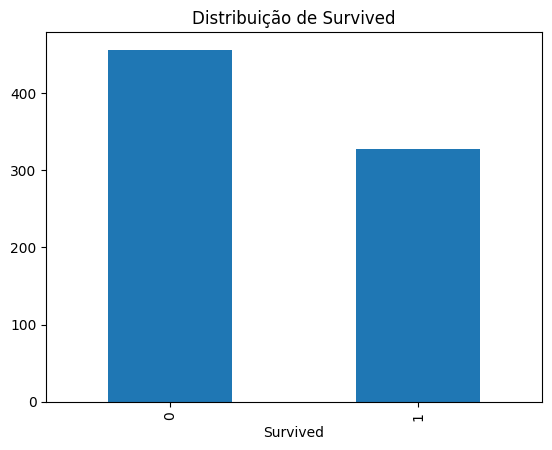

In [ ]:
# Taxa de sobrevivência por classe (Pclass)
df.groupby('Pclass')['Survived'].mean()

Pclass
1.0    0.572222
2.0    0.460000
3.0    0.227979
Name: Survived, dtype: float64

In [ ]:
# Taxa de sobrevivência por sexo
df.groupby('Sex')['Survived'].mean()

Sex
0.0    0.188034
1.0    0.693548
Name: Survived, dtype: float64

In [ ]:
# Distribuição de Age e Fare por sobrevivência
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=df, x='Survived', y='Age', ax=axes[0])
sns.boxplot(data=df, x='Survived', y='Fare', ax=axes[1])
plt.show()

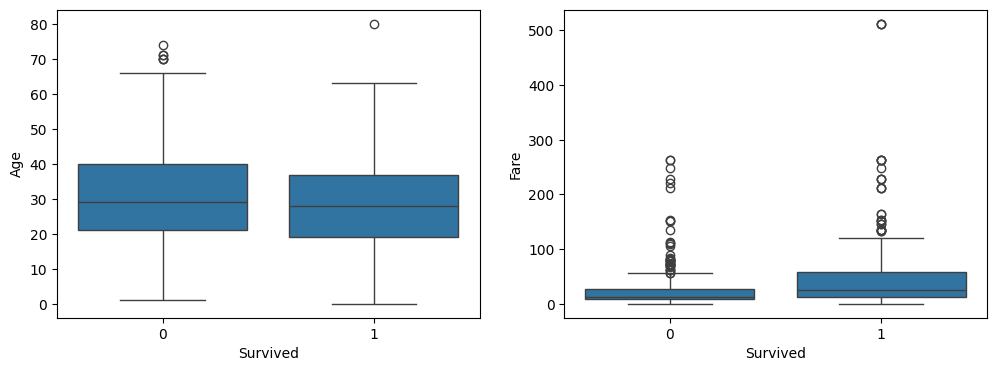

In [ ]:
# Matriz de correlação entre os atributos numéricos
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

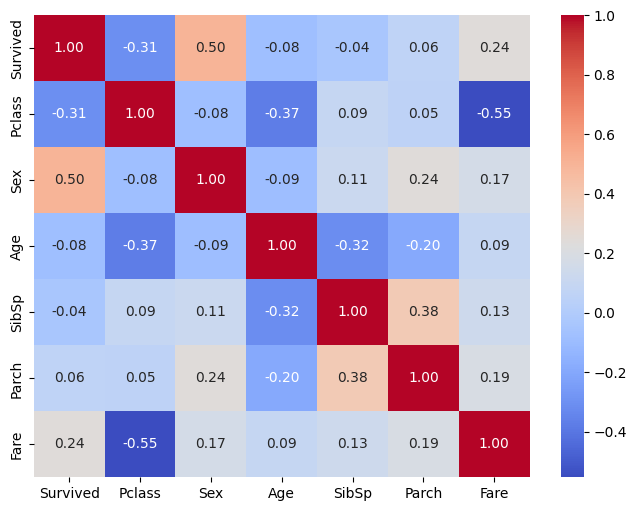

In [ ]:
df_viz = pd.get_dummies(df, columns=['Embarked'], dtype=int)
sns.pairplot(df_viz, hue='Survived')
plt.show()

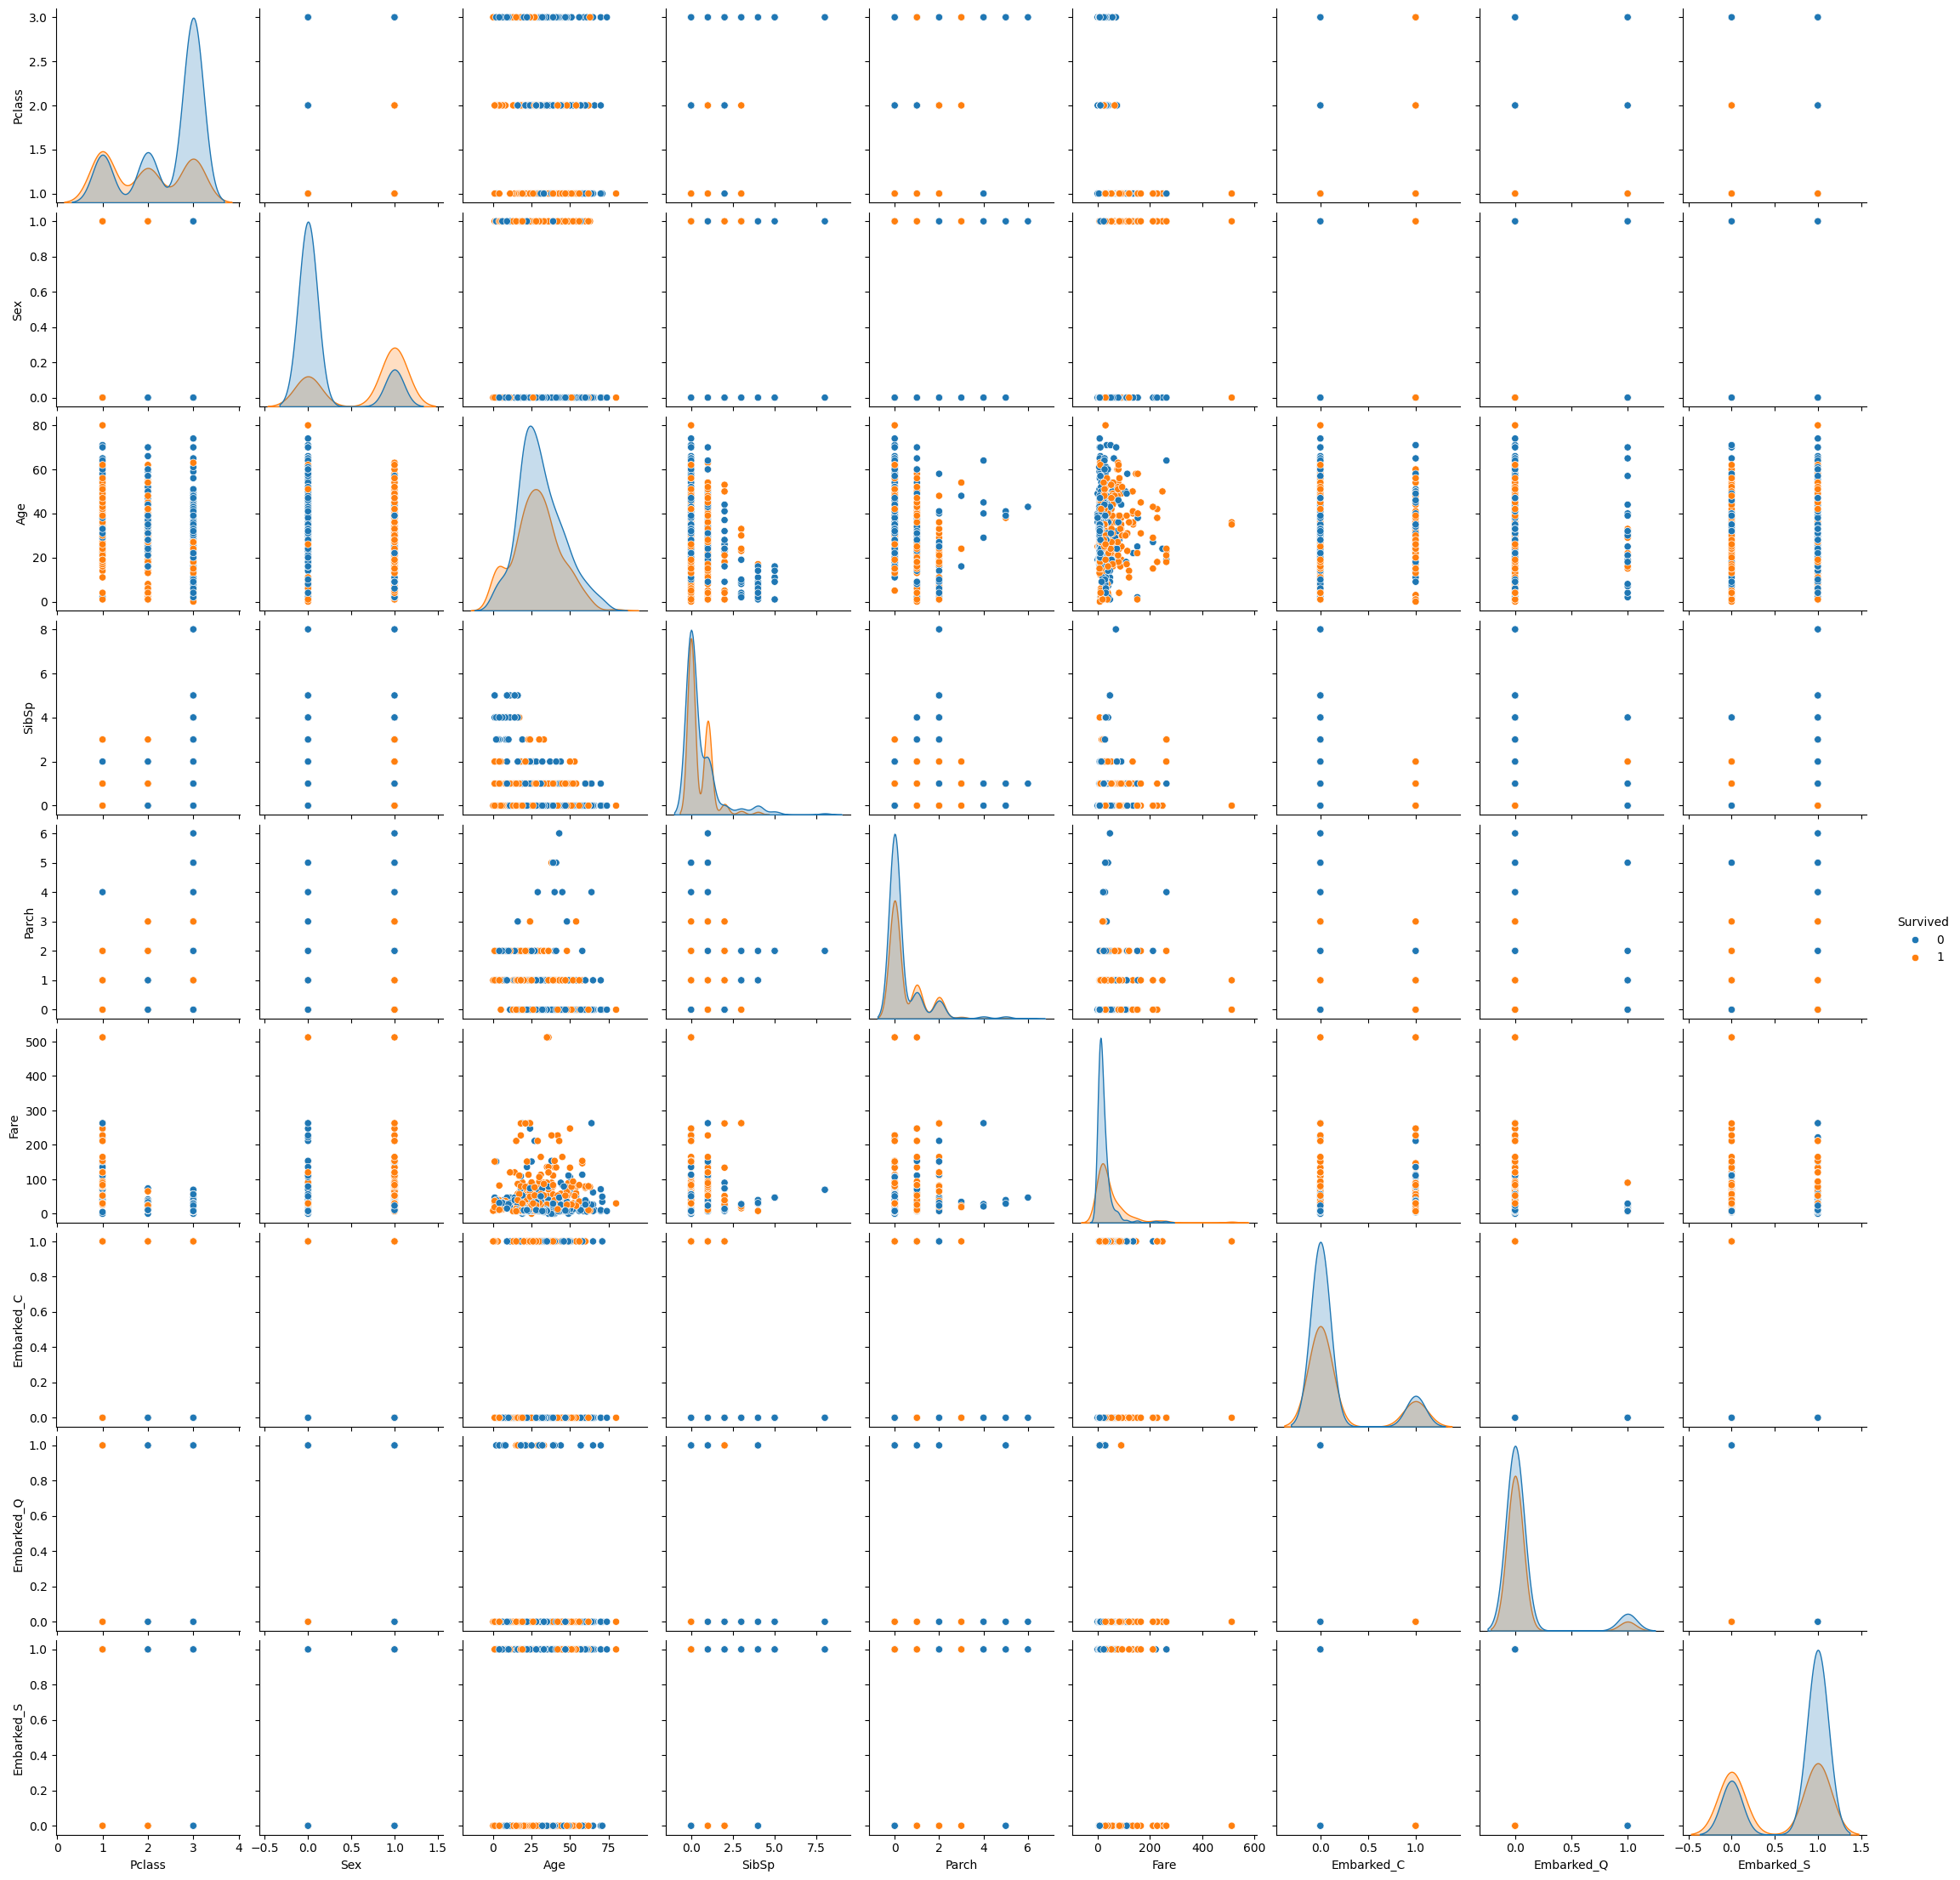

In [ ]:
# Pairplot só com um subconjunto para facilitar a visualização
sns.pairplot(df_viz, vars=['Pclass','Age','Fare','SibSp','Parch'], hue='Survived')
plt.show()

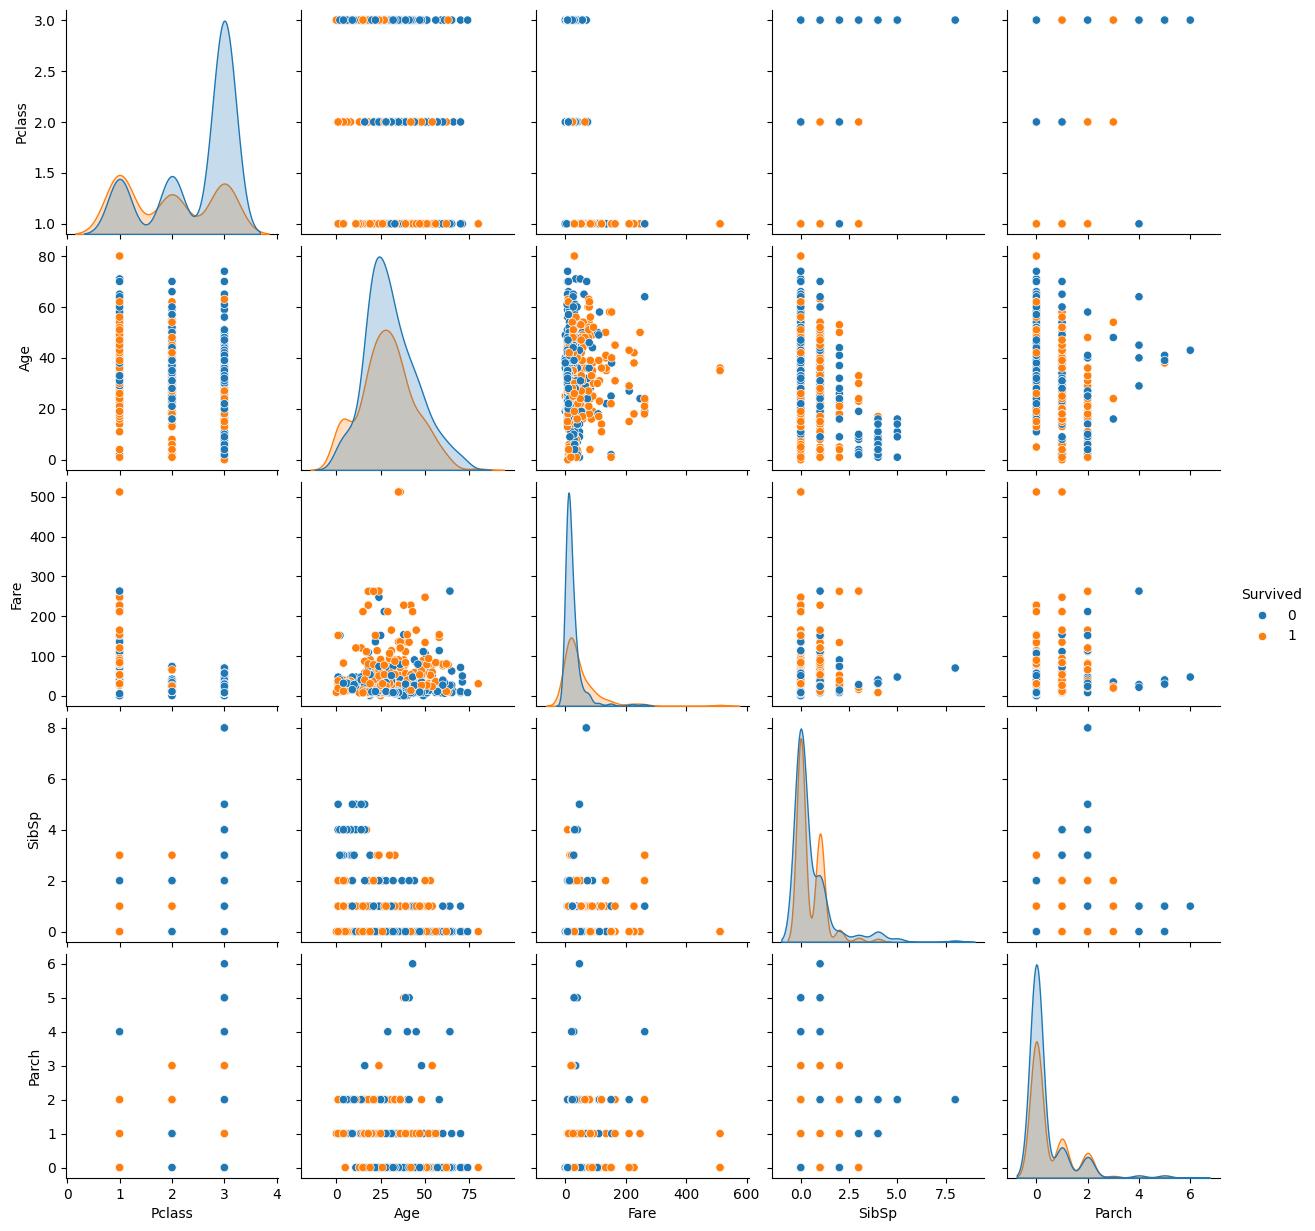

#3) Preenchimento de dados faltantes

Após a formatação e seleção das colunas relevantes, você deve garantir que todas as colunas estejam com dados válidos em cada coluna.

Para isso, você deve preencher os dados faltantes das colunas usando o algoritmo de agrupamento K-means.

Os passos desse processo são:

Passo 1: Crie um segundo dataset (dataset 2) sem as colunas com dados faltantes.

![Passo1](https://drive.google.com/uc?export=download&id=1dBpwbuWW-I_6_paIQNlfGER2ZZinZ59R)


Passo 2: Aplique o K-means no dataset 2 para gerar clusters de tuplas com características semelhantes.

![Passo2](https://drive.google.com/uc?export=download&id=1mNPNPdecWCqMraoS57a6TQKjkhGDgUHU)

Passo 3: Para cada cluster, selecione as tuplas que não possuam dados faltantes.

![Passo3](https://drive.google.com/uc?export=download&id=1xLwkPSjjxuZpW2zzk0k_-w3-AmvN84gj)

Passo 4: Para as tuplas selecionadas, calcula o atributo estatístico mais adequado para a coluna (média, mediana, moda, etc).

![Passo4](https://drive.google.com/uc?export=download&id=1zt35CNY_CWSGX_igHsA_AWKNZl34TM8K)

Passo 5: Para cada tupla com dados faltantes, utilize o atributo estatístico referente ao seu grupo para preencher o dado da coluna.

![Passo5](https://drive.google.com/uc?export=download&id=1rEvU-6eaQURjzIrblpIiA7b-FFYj_bRD)


In [ ]:
# Insira seu código aqui
# Você pode adicionar células adicionais

# TODO
# 1) Gerar o dataset sem as colunas com dados faltantes
# 2) Aplicar o K-means no novo dataset (explorando o melhor valor de K)
# 3) Cálcular um atributo estatístico (média, moda, mediana, etc), no dataset original, das colunas com dados faltantes
# 4) Preencher os valores das linhas com dados faltantes com o atributo estatístico referente ao seu grupo do K-means

In [ ]:
# Tuplas e dados faltantes
target_cols = ['Pclass', 'Sex', 'Age', 'Embarked']
print(df[target_cols].isnull().sum())

missing_mask = df[target_cols].isnull().any(axis=1)
missing_ids = df[missing_mask].index.tolist()
print(f'\nValor total de tuplas que possuem algum atributo faltante: {len(missing_ids)}')

Pclass       67
Sex          67
Age         106
Embarked     69
dtype: int64

Valor total de tuplas que possuem algum atributo faltante: 165

In [ ]:
ds2_cols = [c for c in df.columns if c not in target_cols]
dataset2 = df[ds2_cols].copy()
print(dataset2.isnull().sum())
dataset2.head().style.background_gradient(cmap='Blues')

Survived    0
SibSp       0
Parch       0
Fare        0
dtype: int64

<style type="text/css">
#T_5f41d_row0_col0, #T_5f41d_row0_col2, #T_5f41d_row0_col3, #T_5f41d_row1_col2, #T_5f41d_row2_col1, #T_5f41d_row2_col2, #T_5f41d_row3_col2, #T_5f41d_row4_col0, #T_5f41d_row4_col1, #T_5f41d_row4_col2 {
  background-color: #f7fbff;
  color: #000000;
}
#T_5f41d_row0_col1, #T_5f41d_row1_col0, #T_5f41d_row1_col1, #T_5f41d_row1_col3, #T_5f41d_row2_col0, #T_5f41d_row3_col0, #T_5f41d_row3_col1 {
  background-color: #08306b;
  color: #f1f1f1;
}
#T_5f41d_row2_col3 {
  background-color: #f5fafe;
  color: #000000;
}
#T_5f41d_row3_col3 {
  background-color: #2a7ab9;
  color: #f1f1f1;
}
#T_5f41d_row4_col3 {
  background-color: #f5f9fe;
  color: #000000;
}
</style>
<table id="T_5f41d">
  <thead>
    <tr>
      <th class="blank level0" >&nbsp;</th>
      <th id="T_5f41d_level0_col0" class="col_heading level0 col0" >Survived</th>
      <th id="T_5f41d_level0_col1" class="col_heading level0 col1" >SibSp</th>
      <th id="T_5f41d_level0_col2" class="col_heading level0 col2" >Parch</th>
      <th id="T_5f41d_level0_col3" class="col_heading level0 col3" >Fare</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th id="T_5f41d_level0_row0" class="row_heading level0 row0" >0</th>
      <td id="T_5f41d_row0_col0" class="data row0 col0" >0</td>
      <td id="T_5f41d_row0_col1" class="data row0 col1" >1</td>
      <td id="T_5f41d_row0_col2" class="data row0 col2" >0</td>
      <td id="T_5f41d_row0_col3" class="data row0 col3" >7.250000</td>
    </tr>
    <tr>
      <th id="T_5f41d_level0_row1" class="row_heading level0 row1" >1</th>
      <td id="T_5f41d_row1_col0" class="data row1 col0" >1</td>
      <td id="T_5f41d_row1_col1" class="data row1 col1" >1</td>
      <td id="T_5f41d_row1_col2" class="data row1 col2" >0</td>
      <td id="T_5f41d_row1_col3" class="data row1 col3" >71.283300</td>
    </tr>
    <tr>
      <th id="T_5f41d_level0_row2" class="row_heading level0 row2" >2</th>
      <td id="T_5f41d_row2_col0" class="data row2 col0" >1</td>
      <td id="T_5f41d_row2_col1" class="data row2 col1" >0</td>
      <td id="T_5f41d_row2_col2" class="data row2 col2" >0</td>
      <td id="T_5f41d_row2_col3" class="data row2 col3" >7.925000</td>
    </tr>
    <tr>
      <th id="T_5f41d_level0_row3" class="row_heading level0 row3" >3</th>
      <td id="T_5f41d_row3_col0" class="data row3 col0" >1</td>
      <td id="T_5f41d_row3_col1" class="data row3 col1" >1</td>
      <td id="T_5f41d_row3_col2" class="data row3 col2" >0</td>
      <td id="T_5f41d_row3_col3" class="data row3 col3" >53.100000</td>
    </tr>
    <tr>
      <th id="T_5f41d_level0_row4" class="row_heading level0 row4" >4</th>
      <td id="T_5f41d_row4_col0" class="data row4 col0" >0</td>
      <td id="T_5f41d_row4_col1" class="data row4 col1" >0</td>
      <td id="T_5f41d_row4_col2" class="data row4 col2" >0</td>
      <td id="T_5f41d_row4_col3" class="data row4 col3" >8.050000</td>
    </tr>
  </tbody>
</table>

In [ ]:
scaler_ds2 = MinMaxScaler()
dataset2_scaled = scaler_ds2.fit_transform(dataset2)
dataset2_scaled[:5]

array([[0.        , 0.125     , 0.        , 0.01415106],
       [1.        , 0.125     , 0.        , 0.13913574],
       [1.        , 0.        , 0.        , 0.01546857],
       [1.        , 0.125     , 0.        , 0.1036443 ],
       [0.        , 0.        , 0.        , 0.01571255]])

In [ ]:
inertias = []
ks = range(2, 11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(dataset2_scaled)
    inertias.append(km.inertia_)

plt.plot(list(ks), inertias, marker='o')
plt.xlabel('Número de clusters K')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo / Elbow Method')
plt.show()

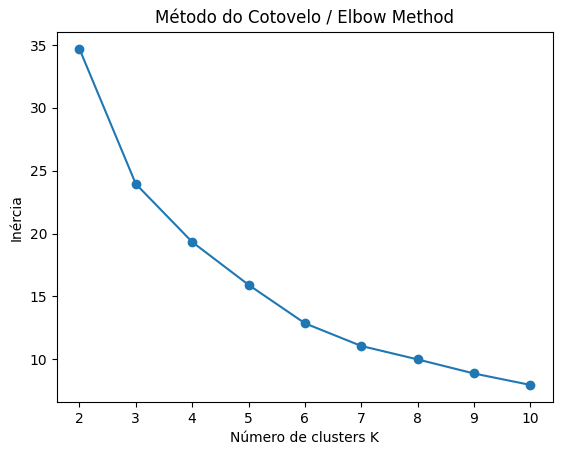

In [ ]:
best_k = 5
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(dataset2_scaled)
df['cluster'].value_counts()

best_k = 5
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(dataset2_scaled)
df['cluster'].value_counts()

In [ ]:
for col in target_cols:
    if col == 'Age':
        stat_por_cluster = df.groupby('cluster')[col].median()
    else:
        stat_por_cluster = df.groupby('cluster')[col].agg(
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    print(f'--- {col} ---')
    print(stat_por_cluster)

    df[col] = df.apply(
        lambda row: stat_por_cluster[row['cluster']] if pd.isnull(row[col]) else row[col],
        axis=1
    )

--- Pclass ---
cluster
0    3.0
1    2.0
2    3.0
3    1.0
4    3.0
Name: Pclass, dtype: float64
--- Sex ---
cluster
0    0.0
1    1.0
2    0.0
3    1.0
4    1.0
Name: Sex, dtype: float64
--- Age ---
cluster
0    30.0
1    22.0
2     7.5
3    30.0
4    37.5
Name: Age, dtype: float64
--- Embarked ---
...
2    S
3    S
4    S
Name: Embarked, dtype: object
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...

In [ ]:
df = df.drop(columns=['cluster'])
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [ ]:
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked')
embarked_cols = [c for c in df.columns if c.startswith('Embarked_')]
df[embarked_cols] = df[embarked_cols].astype(int)
df.head()

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Survived</th>
      <th>Pclass</th>
      <th>Sex</th>
      <th>Age</th>
      <th>SibSp</th>
      <th>Parch</th>
      <th>Fare</th>
      <th>Embarked_C</th>
      <th>Embarked_Q</th>
      <th>Embarked_S</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>0</td>
      <td>3.0</td>
      <td>0.0</td>
      <td>22.0</td>
      <td>1</td>
      <td>0</td>
      <td>7.2500</td>
      <td>0</td>
      <td>0</td>
      <td>1</td>
    </tr>
    <tr>
      <th>1</th>
      <td>1</td>
      <td>1.0</td>
      <td>1.0</td>
      <td>38.0</td>
      <td>1</td>
      <td>0</td>
      <td>71.2833</td>
      <td>1</td>
      <td>0</td>
      <td>0</td>
    </tr>
    <tr>
      <th>2</th>
      <td>1</td>
      <td>3.0</td>
      <td>1.0</td>
      <td>26.0</td>
      <td>0</td>
      <td>0</td>
      <td>7.9250</td>
      <td>0</td>
      <td>0</td>
      <td>1</td>
    </tr>
    <tr>
      <th>3</th>
      <td>1</td>
      <td>1.0</td>
      <td>1.0</td>
      <td>35.0</td>
      <td>1</td>
      <td>0</td>
      <td>53.1000</td>
      <td>0</td>
      <td>0</td>
      <td>1</td>
    </tr>
    <tr>
      <th>4</th>
      <td>0</td>
      <td>3.0</td>
      <td>0.0</td>
      <td>35.0</td>
      <td>0</td>
      <td>0</td>
      <td>8.0500</td>
      <td>0</td>
      <td>0</td>
      <td>1</td>
    </tr>
  </tbody>
</table>
</div>

In [ ]:
# Para confirmar as listas
df.columns.tolist()

['Survived',
 'Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Embarked_C',
 'Embarked_Q',
 'Embarked_S']

In [ ]:
df.dtypes

Survived        int64
Pclass        float64
Sex           float64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_C      int64
Embarked_Q      int64
Embarked_S      int64
dtype: object

# 4) Escala dos atributos

Agora, você precisa reescalar os dados, para que os algoritmos consigam aprender as relações entre os dados sem muito ruído e melhora a classificação.

Lembre-se de verificar e tratar colunas com outliers.

In [ ]:
# Insira seu código aqui
# Você pode adicionar células adicionais

# TODO
# 1) Verificar quais dados possuem outliers e tratar de acordo
# 2) Reescalar os dados

In [ ]:
# Outliers
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, col in zip(axes, ['Age','Fare','SibSp','Parch']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

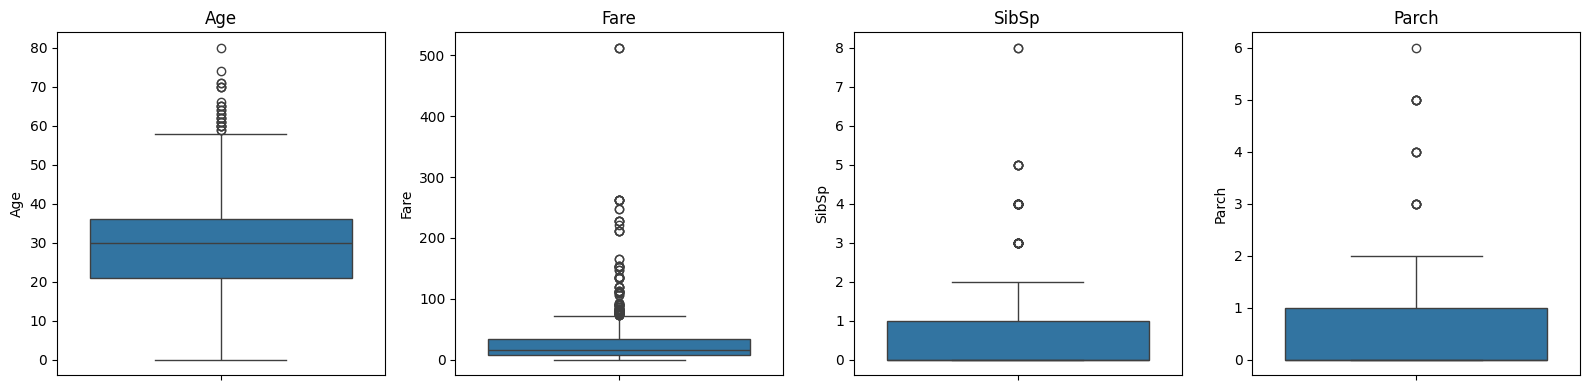

In [ ]:
q99 = df['Fare'].quantile(0.99)
print(f'Percentil 99 de Fare: {q99:.2f}')
df['Fare'] = df['Fare'].clip(upper=q99)

sns.boxplot(y=df['Fare'])
plt.title('Fare após tratamento de outliers')
plt.show()

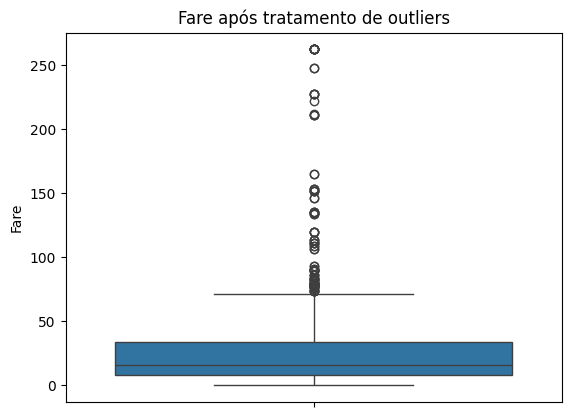

In [ ]:
scale_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
scaler = MinMaxScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])
df.describe()

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Survived</th>
      <th>Pclass</th>
      <th>Sex</th>
      <th>Age</th>
      <th>SibSp</th>
      <th>Parch</th>
      <th>Fare</th>
      <th>Embarked_C</th>
      <th>Embarked_Q</th>
      <th>Embarked_S</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>count</th>
      <td>783.000000</td>
      <td>783.000000</td>
      <td>783.000000</td>
      <td>783.000000</td>
      <td>783.000000</td>
      <td>783.000000</td>
      <td>783.000000</td>
      <td>783.000000</td>
      <td>783.000000</td>
      <td>783.000000</td>
    </tr>
    <tr>
      <th>mean</th>
      <td>0.417625</td>
      <td>0.604087</td>
      <td>0.402299</td>
      <td>0.371919</td>
      <td>0.065453</td>
      <td>0.069391</td>
      <td>0.128750</td>
      <td>0.167305</td>
      <td>0.071520</td>
      <td>0.761175</td>
    </tr>
    <tr>
      <th>std</th>
      <td>0.493483</td>
      <td>0.428772</td>
      <td>0.490675</td>
      <td>0.172695</td>
      <td>0.123336</td>
      <td>0.139554</td>
      <td>0.172328</td>
      <td>0.373487</td>
      <td>0.257856</td>
      <td>0.426638</td>
    </tr>
    <tr>
      <th>min</th>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>0.000000</td>
    </tr>
    <tr>
      <th>25%</th>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>0.262500</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>0.030681</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>1.000000</td>
    </tr>
    <tr>
      <th>50%</th>
      <td>0.000000</td>
      <td>0.500000</td>
      <td>0.000000</td>
      <td>0.375000</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>0.060600</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>1.000000</td>
    </tr>
    <tr>
      <th>75%</th>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>0.450000</td>
      <td>0.125000</td>
      <td>0.166667</td>
      <td>0.130340</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>1.000000</td>
    </tr>
    <tr>
      <th>max</th>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
    </tr>
  </tbody>
</table>
</div>

# 5) Balanceamento da coluna alvo

Por fim, você precisa balancear a coluna alvo. Use algum método visto em aula para balancear a coluna alvo definida no enunciado da Fase 1.

In [ ]:
# Desbalanceamento (?)
df['Survived'].value_counts()

Survived
0    456
1    327
Name: count, dtype: int64

In [ ]:
majoritaria = df[df['Survived'] == 0]
minoritaria = df[df['Survived'] == 1]
minoritaria_upsampled = minoritaria.sample(n=len(majoritaria), replace=True, random_state=42)
df_balanced = pd.concat([majoritaria, minoritaria_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
df_balanced['Survived'].value_counts()

Survived
1    456
0    456
Name: count, dtype: int64

In [ ]:
print('Shape final:', df_balanced.shape)
print('\nValores nulos:')
print(df_balanced.isnull().sum().sum())
print('\nLinhas duplicadas:', df_balanced.duplicated().sum())
print('\nTipos de dados:')
print(df_balanced.dtypes)
df_balanced.head()

Shape final: (912, 10)

Valores nulos:
0

Linhas duplicadas: 219

Tipos de dados:
Survived        int64
Pclass        float64
Sex           float64
Age           float64
SibSp         float64
Parch         float64
Fare          float64
Embarked_C      int64
Embarked_Q      int64
Embarked_S      int64
dtype: object

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Survived</th>
      <th>Pclass</th>
      <th>Sex</th>
      <th>Age</th>
      <th>SibSp</th>
      <th>Parch</th>
      <th>Fare</th>
      <th>Embarked_C</th>
      <th>Embarked_Q</th>
      <th>Embarked_S</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>1</td>
      <td>0.5</td>
      <td>1.0</td>
      <td>0.4250</td>
      <td>0.000</td>
      <td>0.000000</td>
      <td>0.049547</td>
      <td>0</td>
      <td>0</td>
      <td>1</td>
    </tr>
    <tr>
      <th>1</th>
      <td>1</td>
      <td>1.0</td>
      <td>1.0</td>
      <td>0.3375</td>
      <td>0.000</td>
      <td>0.166667</td>
      <td>0.047546</td>
      <td>0</td>
      <td>0</td>
      <td>1</td>
    </tr>
    <tr>
      <th>2</th>
      <td>1</td>
      <td>0.5</td>
      <td>1.0</td>
      <td>0.1000</td>
      <td>0.000</td>
      <td>0.333333</td>
      <td>0.100048</td>
      <td>0</td>
      <td>0</td>
      <td>1</td>
    </tr>
    <tr>
      <th>3</th>
      <td>0</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.3750</td>
      <td>0.000</td>
      <td>0.000000</td>
      <td>0.101191</td>
      <td>0</td>
      <td>0</td>
      <td>1</td>
    </tr>
    <tr>
      <th>4</th>
      <td>0</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.6125</td>
      <td>0.125</td>
      <td>0.166667</td>
      <td>0.422614</td>
      <td>1</td>
      <td>0</td>
      <td>0</td>
    </tr>
  </tbody>
</table>
</div>

In [ ]:
df_balanced.to_csv('TitanicNovoDataset.csv', index=False)
print('Dataset salvo com sucesso!')

Dataset salvo com sucesso!

# Check-List

Com isso, você completa a fase 1 da disciplina. Para auxiliar você a verificar se o trabalho está adequado para a entrega, criamos uma lista de item que devem ser satisfeitos ao final do trabalho.

- Remoção das colunas que não acrescentam informações úteis;
- Todas as colunas estão com a sua representação unificada;
- Todas as colunas estão no formato numérico;
- Todas as colunas estão com dados válidos (sem dados falantes);
- Todas as colunas estão reescaladas;
- Coluna alvo balanceada.
